In [2]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 8.7 MB/s eta 0:00:00


In [54]:
import numpy as np
import control as ctrl
from matplotlib import pyplot as plt
import sympy as sp
from scipy import signal as signal

In [55]:
# Download the actual raw CSVs
!curl -L -o output_gaussiana_larga.csv https://raw.githubusercontent.com/fadellavedova/control_adaptativo/master/mediciones/output_gaussiana_larga.csv
!curl -L -o input_gaussiana_larga.csv https://raw.githubusercontent.com/fadellavedova/control_adaptativo/master/mediciones/input_gaussiana_larga.csv
!curl -L -o tiempo2.csv https://raw.githubusercontent.com/fadellavedova/control_adaptativo/master/mediciones/tiempo2.csv

# Now load numeric data
output = np.loadtxt("output_gaussiana_larga.csv", skiprows = 1)[100:-1]
input = np.loadtxt("input_gaussiana_larga.csv", skiprows = 1)[100:-1]
treal = np.loadtxt("tiempo2.csv", skiprows = 1)[100:-1]



  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  403k  100  403k    0     0   616k      0 --:--:-- --:--:-- --:--:--  618k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  285k  100  285k    0     0   275k      0  0:00:01  0:00:01 --:--:--  275k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  270k  100  270k    0     0   270k      0 --:--:-- --:--:-- --:--:--  271k


#Respuesta al impulso con correlacion

99.91054083223408
0.42827642016069073
99.99199705730261


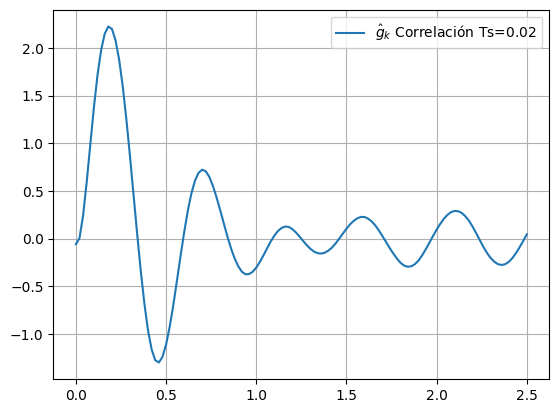

In [56]:
out_muestra_ext = output
in_muestra_ext = input[:len(output)]

M = 250
N = len(in_muestra_ext)
Ts = 0.02


var = np.var(in_muestra_ext)
mean_in = np.mean(in_muestra_ext)
mean_out = np.mean(out_muestra_ext)

print(mean_in)
print(mean_out)
print(var)

in_muestra_ext = in_muestra_ext - mean_in
out_muestra_ext = out_muestra_ext - mean_out

ruu = np.correlate(in_muestra_ext, in_muestra_ext, mode="full")/N  # correlación completa
mid = len(ruu)//2                      # índice de lag=0
lags = np.arange(-M//2,M//2+1)

ryu = np.correlate(out_muestra_ext, in_muestra_ext, mode="full")/N  # correlación completa
g_hat_corr = ryu[mid+np.arange(0,M)]



# Graficar
idx_lag = np.arange(0,M//2+1)
plt.plot(idx_lag*Ts,g_hat_corr[idx_lag]/Ts,'-',label=f'$\\hat{{g}}_k$ Correlación Ts={Ts}')

plt.legend()
plt.grid()
plt.show()

#Cociente de correlogramas para conseguir el bode aproximado

<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:32: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipython-input-1874067981.py:32: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ [rad/s]')


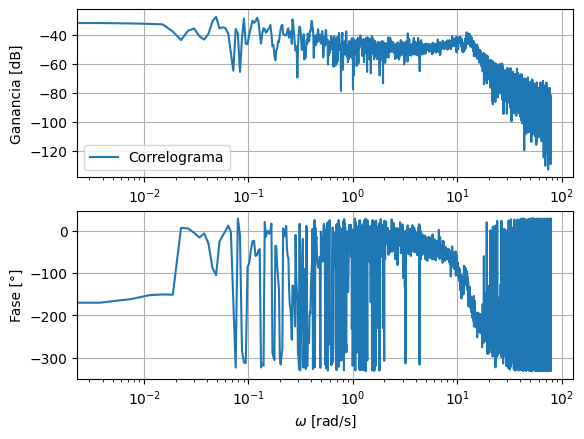

In [57]:
from scipy.signal import csd, welch

window = True
plot=True

win = np.ones_like(ruu)
if window:
    win = signal.windows.hann(len(ruu))

Puy = np.fft.fft(ryu*win)
Puu = np.fft.fft(ruu*win)
w = np.fft.fftfreq(len(ruu), Ts)*2*np.pi
G_corr = Puy/Puu

mag_ident= np.abs(G_corr[0:N//2])
phase_ident = np.angle(G_corr[0:N//2])
phase_ident = np.where(phase_ident > 0.5, phase_ident - 2*np.pi, phase_ident)
phase_ident *= 180/np.pi
w_ident = w[0:N//2]

if plot:
    plt.figure()
    plt.subplot(211)
    plt.semilogx(w_ident,20*np.log10(mag_ident),label='Correlograma')
    #plt.xlim(w_min,w_max)
    plt.ylabel('Ganancia [dB]')
    plt.legend()
    plt.grid()
    plt.subplot(212)
    plt.semilogx(w_ident,phase_ident,label='Correlograma')
    plt.ylabel('Fase [°]')
    plt.xlabel('$\omega$ [rad/s]')
    #plt.legend()
    plt.grid()

#Estimacion de parametros con orden 2 en numerador y denominador

Se prueban estimadores diseñados para distintos modelos para definir la forma del sistema

In [58]:
###Separamos los conjuntos de la tira original de datos entre testeo y validacion, el primer 80% de muestras y despues el resto
input_80 = input[:34000]
output_80 = output[:34000]
treal_80 = treal[:34000]

input_resto = input[34000:]
output_resto = output[34000:]
treal_resto = treal[34000:]

In [59]:
print(input_80.shape)
print(input_resto.shape)

(34000,)
(49492,)


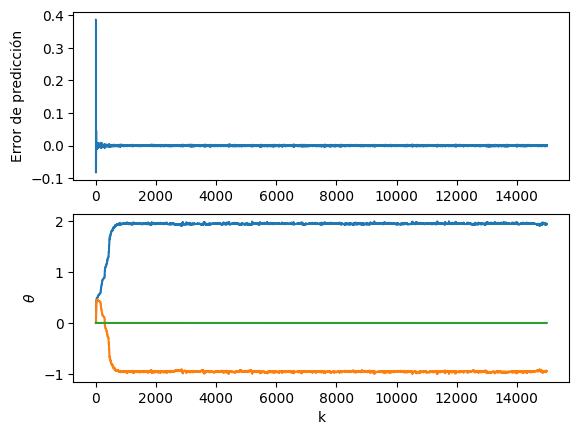

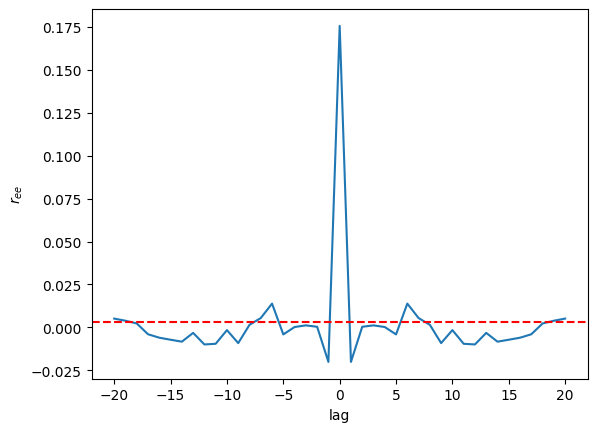

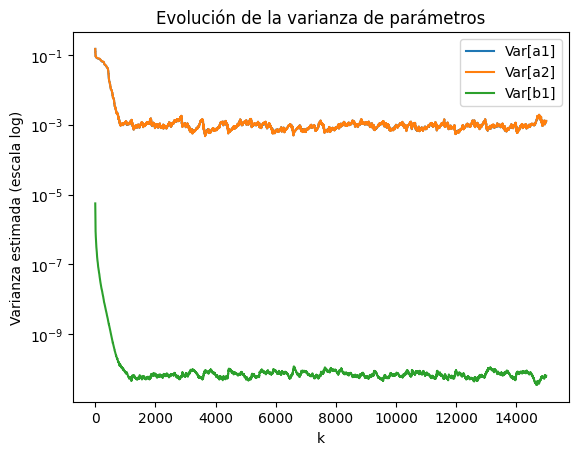

In [103]:
def estimador_RLS(u,y,na=2, nb=1, lambda_=1,theta_real=None,plot=True):
    N = len(u)
    theta_hat = np.zeros(na+nb)       # estimación inicial [a_hat, b_hat]
    P = 100 * np.eye(na+nb)          # matriz de covarianza grande
    err = np.zeros_like(y)

    lambda_sigma = 0.99
    sigma2_hat = 0.0

    theta_hist = []
    P_hist = []
    sigma2_hist = []

    k_range = range(na+1, N)
    for k in k_range:
        phi = np.concatenate((y[k-1:k-na-1:-1], u[k-1:k-nb-1:-1]))   # vector de regresores
        y_hat = phi @ theta_hat
        err[k] = y[k] - y_hat

        K = P @ phi / (lambda_ + phi.T @ P @ phi)
        theta_hat = theta_hat + K * err[k]
        P = (P - np.outer(K, phi) @ P) / lambda_
        sigma2_hat = lambda_sigma * sigma2_hat + (1 - lambda_sigma) * (err[k]**2)
        sigma2_hist.append(sigma2_hat)

        theta_hist.append(theta_hat.copy())
        P_hist.append(np.diag(P).copy())

    theta_hist = np.array(theta_hist)
    P_hist = np.array(P_hist)
    sigma2_hist = np.array(sigma2_hist)

    if plot:
        plt.subplot(211)
        plt.step(k_range,err[k_range],where='post')
        #plt.xlabel('Tiempo [s]')
        plt.ylabel('Error de predicción')
        plt.subplot(212)
        for idx_na in range(0,na):
            plt.step(k_range,theta_hist[:,idx_na], label=f"$\\hat{{a_{idx_na+1}}}$",where='post')
        for idx_nb in range(0,nb):
            plt.step(k_range,theta_hist[:,na+idx_nb], label=f"$\\hat{{b_{idx_nb+1}}}$",where='post')
        if theta_real!=None:
            colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
            for idx_na in range(na):
                color = colors[idx_na % len(colors)]
                plt.axhline(theta_real[idx_na], linestyle='--', color=color, label=f"$a_{idx_na}$")
            for idx_nb in range(nb):
                color = colors[(idx_nb+na) % len(colors)]
                plt.axhline(theta_real[idx_nb+na], linestyle='--', color=color, label=f"$b_{idx_nb}$")
        #plt.legend()
        plt.xlabel('k')
        plt.ylabel('$\\theta$')
        plt.show()

        # Observemos la correlación del error de predicción
        N_lag = 20
        ree = np.correlate(err,err,'full')
        lags = np.arange(-len(err)+1, len(err))
        center = len(ree) // 2
        ree = ree[center-N_lag:center+N_lag+1]
        lags_plot = lags[center-N_lag:center+N_lag+1]
        ree_max_val = 2.17/np.sqrt(N)*ree[N_lag]
        plt.figure()
        plt.plot(lags_plot,ree)
        plt.ylabel('$r_{{ee}}$')
        plt.xlabel('lag')
        plt.axhline(ree_max_val, linestyle='--', color='r', label=f"$ree_{{max}}$")
        plt.plot()

        var_a1 = sigma2_hist * P_hist[:,0]
        var_a2 = sigma2_hist * P_hist[:,1]
        var_b1 = sigma2_hist * P_hist[:,2]
   #     var_b2 = sigma2_hist * P_hist[:,3]

        plt.figure()
        plt.semilogy(var_a1, label='Var[a1]')
        plt.semilogy(var_a2, label='Var[a2]')
        plt.semilogy(var_b1, label='Var[b1]')
     #   plt.semilogy(var_b2, label='Var[b2]')
        plt.xlabel('k')
        plt.ylabel('Varianza estimada (escala log)')
        plt.legend()
        plt.title('Evolución de la varianza de parámetros')
        plt.show()


        return theta_hist,P
# --- Data ---
y = output_80[:15000]
u = input_80[:15000]
N = len(y)
naa = 2

theta_hat,P = estimador_RLS(u,y,lambda_=0.99,na=naa,nb=1)

In [104]:
print(theta_hat[-1])
est = [1]

est.extend(list(-theta_hat[-1][:naa]))
poly_coeffs = np.array(est)

# Calcular raíces
polos = [np.roots(poly_coeffs)]#,np.roots(poly_coeffs1),np.roots(poly_coeffs2)]

print("Los polos del sistema son:")
for a in polos:
  for p in a:
      estado = "INESTABLE" if abs(p) > 1 else "Estable"
      print(f"z = {p:.4f}  ---> Magnitud: {abs(p):.4f} ({estado})")

T = 0.02  # REEMPLAZA ESTO con tu tiempo de muestreo real

print("\nPolos en continuo (plano S):")
for a in polos:
  for p in a:
      s = np.log(p) / T
      print(f"s = {s.real:.4f} + {s.imag:.4f}j {p}")

print(est)

[ 1.93502996e+00 -9.39086111e-01  1.67912926e-05]
Los polos del sistema son:
z = 0.9675+0.0548j  ---> Magnitud: 0.9691 (Estable)
z = 0.9675-0.0548j  ---> Magnitud: 0.9691 (Estable)

Polos en continuo (plano S):
s = -1.5712 + 2.8280j (0.9675149817830977+0.05478021013610732j)
s = -1.5712 + -2.8280j (0.9675149817830977-0.05478021013610732j)
[1, np.float64(-1.9350299635661954), np.float64(0.9390861113973039)]


##Como el sistema no pasa la prueba de la blancura, cambiamos el modelo para tener en cuenta el ruido, ya que este no queda como ruido blanco.

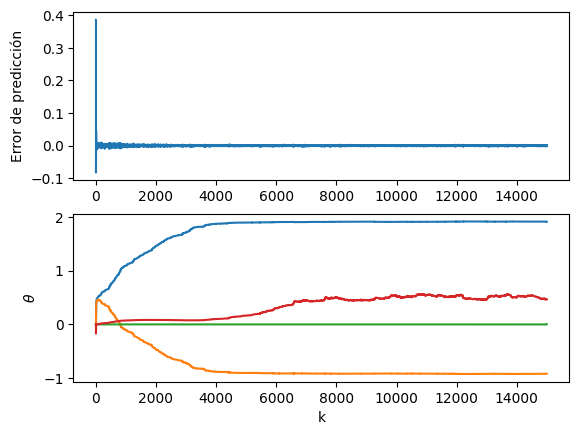

[1.49498197e-01 1.49412716e-01 1.30761013e-01 ... 8.36445054e-05
 8.57008296e-05 8.55030791e-05]


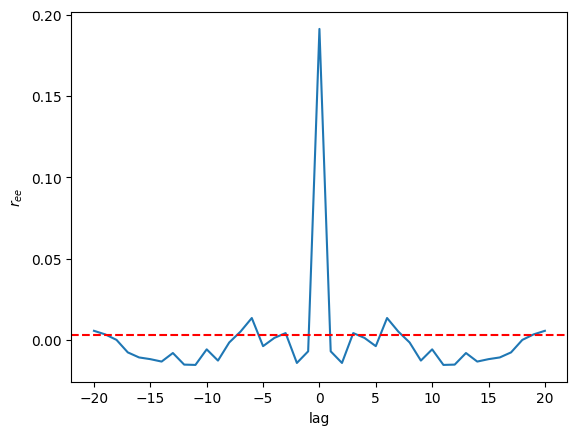

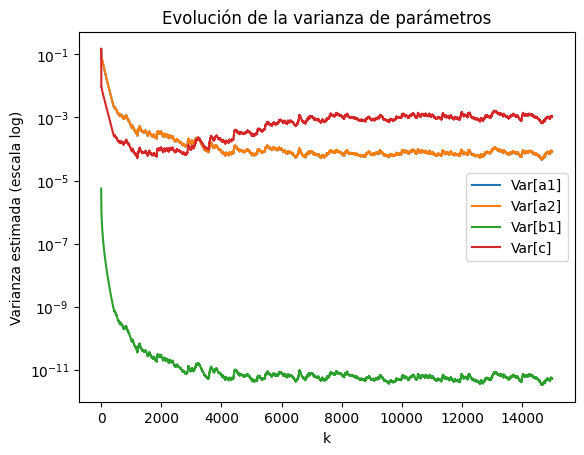

In [105]:
# Estimador por mínimos cuadrados extendido para un modelo ARX con ruido coloreado
def estimador_ELS(u,y,na=1, nb=1, nc=1, lambda_=1,theta_real=None,plot=True):
    N = len(u)
    theta_hat = np.zeros(na+nb+nc)       # estimación inicial [a_hat, b_hat]
    P = 100 * np.eye(na+nb+nc)          # matriz de covarianza grande
    err = np.zeros_like(y)

    lambda_sigma = 0.99
    sigma2_hat = 0.0

    theta_hist = []
    P_hist = []
    sigma2_hist = []

    k_range = range(na+1, N)
    for k in k_range:
        phi = np.concatenate((y[k-1:k-na-1:-1], u[k-1:k-nb-1:-1], err[k-1:k-nc-1:-1]))   # vector de regresores
     #   phi[1] = np.sin(phi[1])
        y_hat = phi @ theta_hat
        err[k] = y[k] - y_hat

        K = P @ phi / (lambda_ + phi.T @ P @ phi)
        theta_hat = theta_hat + K * err[k]
        P = (P - np.outer(K, phi) @ P) / lambda_

        sigma2_hat = lambda_sigma * sigma2_hat + (1 - lambda_sigma) * (err[k]**2)
        sigma2_hist.append(sigma2_hat)

        theta_hist.append(theta_hat.copy())
        P_hist.append(np.diag(P).copy())

    theta_hist = np.array(theta_hist)
    P_hist = np.array(P_hist)
    sigma2_hist = np.array(sigma2_hist)

    if plot:
        plt.subplot(211)
        plt.step(k_range,err[k_range],where='post')
        #plt.xlabel('Tiempo [s]')
        plt.ylabel('Error de predicción')
        plt.subplot(212)
        for idx_na in range(0,na):
            plt.step(k_range,theta_hist[:,idx_na], label=f"$\\hat{{a_{idx_na+1}}}$",where='post')
        for idx_nb in range(0,nb):
            plt.step(k_range,theta_hist[:,na+idx_nb], label=f"$\\hat{{b_{idx_nb+1}}}$",where='post')
        for idx_nc in range(0,nc):
            plt.step(k_range,theta_hist[:,na+nb+idx_nc], label=f"$\\hat{{c_{idx_nc+1}}}$",where='post')
        if theta_real!=None:
            colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
            for idx_na in range(na):
                color = colors[idx_na % len(colors)]
                plt.axhline(theta_real[idx_na], linestyle='--', color=color, label=f"$a_{idx_na}$")
            for idx_nb in range(nb):
                color = colors[(idx_nb+na) % len(colors)]
                plt.axhline(theta_real[idx_nb+na], linestyle='--', color=color, label=f"$b_{idx_nb}$")
            for idx_nc in range(nc):
                color = colors[(idx_nc+na+nb) % len(colors)]
                plt.axhline(theta_real[idx_nc+na+nb], linestyle='--', color=color, label=f"$c_{idx_nc}$")
        #plt.legend()
        plt.xlabel('k')
        plt.ylabel('$\\theta$')
        plt.show()

        # Observemos la correlación del error de predicción
        N_lag = 20
        ree = np.correlate(err,err,'full')
        lags = np.arange(-len(err)+1, len(err))
        center = len(ree) // 2
        ree = ree[center-N_lag:center+N_lag+1]
        lags_plot = lags[center-N_lag:center+N_lag+1]
        ree_max_val = 2.17/np.sqrt(N)*ree[N_lag]
        plt.figure()
        plt.plot(lags_plot,ree)
        plt.ylabel('$r_{{ee}}$')
        plt.xlabel('lag')
        plt.axhline(ree_max_val, linestyle='--', color='r', label=f"$ree_{{max}}$")
        plt.plot()
        #print(f"Error en 0 1 2 , {ree[0], ree[1] , ree[2], np.max(ree)}")
        var_a1 = sigma2_hist * P_hist[:,0]
        var_a2 = sigma2_hist * P_hist[:,1]
        var_b1 = sigma2_hist * P_hist[:,2]
        #var_b2 = sigma2_hist * P_hist[:,3]
        var_c = sigma2_hist * P_hist[:,3]
        print(var_a1)
        plt.figure()
        plt.semilogy(var_a1, label='Var[a1]')
        plt.semilogy(var_a2, label='Var[a2]')
        plt.semilogy(var_b1, label='Var[b1]')
        #plt.semilogy(var_b2, label='Var[b2]')
        plt.semilogy(var_c, label='Var[c]')
        plt.xlabel('k')
        plt.ylabel('Varianza estimada (escala log)')
        plt.legend()
        plt.title('Evolución de la varianza de parámetros')
        plt.show()


        return theta_hist,P

# --- Data ---
y = output_80[:15000]
u = input_80[:15000]
N = len(y)
naaels = 2

theta_hatELS,P = estimador_ELS(u,y,lambda_=0.999,na=naaels,nb=1,nc=1)



In [106]:
print(theta_hatELS[-1])
est = [1]
est.extend(list(-theta_hatELS[-1][:naaels]))
poly_coeffs = np.array(est)

# Calcular raíces
polos = [np.roots(poly_coeffs)]#,np.roots(poly_coeffs1),np.roots(poly_coeffs2)]

print("Los polos del sistema son:")
for a in polos:
  for p in a:
      estado = "INESTABLE" if abs(p) > 1 else "Estable"
      print(f"z = {p:.4f}  ---> Magnitud: {abs(p):.4f} ({estado})")

T = 0.02  # REEMPLAZA ESTO con tu tiempo de muestreo real

print("\nPolos en continuo (plano S):")
for a in polos:
  for p in a:
      s = np.log(p) / T
      print(f"s = {s.real:.4f} + {s.imag:.4f}j {p}")

print(est)

[ 1.91310551e+00 -9.18285347e-01  2.18912744e-05  4.65377002e-01]
Los polos del sistema son:
z = 0.9566+0.0574j  ---> Magnitud: 0.9583 (Estable)
z = 0.9566-0.0574j  ---> Magnitud: 0.9583 (Estable)

Polos en continuo (plano S):
s = -2.1312 + 2.9956j (0.9565527551719957+0.05737746149160095j)
s = -2.1312 + -2.9956j (0.9565527551719957-0.05737746149160095j)
[1, np.float64(-1.9131055103439913), np.float64(0.9182853465143561)]


##La estimacion mejora pero aun no pasa la prueba de la blancura

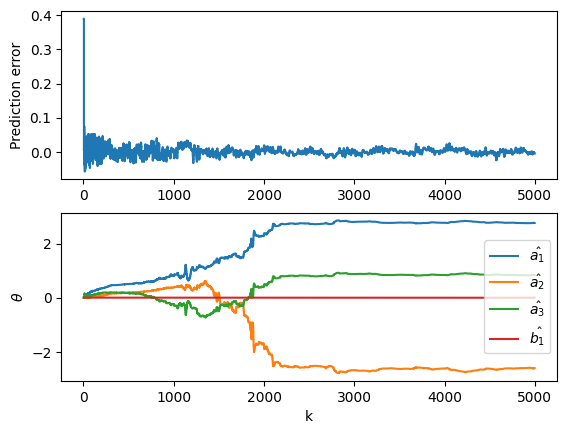

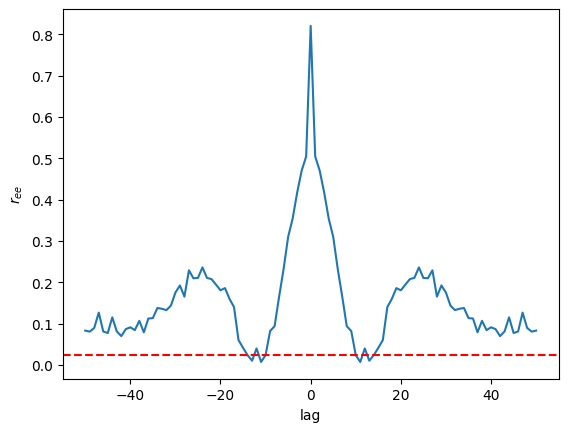

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def estimador_OE(u, y, na=3, nb=1, lambda_=0.99, theta_real=None, plot=True):
    N = len(y)
    n_params = na + nb
    theta = np.zeros(n_params)
    P = np.eye(n_params) * 100.0

    # --- Predictor memory ---
    y_hat_prev = 0.0
    y_hat_prev_prev = 0.0
    y_hat_prev_prev_prev = 0.0

    # --- Sensitivity memory (3 levels for each parameter) ---
    s_a1_prev, s_a1_prev_prev, s_a1_prev_prev_prev = 0.0, 0.0, 0.0
    s_a2_prev, s_a2_prev_prev, s_a2_prev_prev_prev = 0.0, 0.0, 0.0
    s_a3_prev, s_a3_prev_prev, s_a3_prev_prev_prev = 0.0, 0.0, 0.0
    s_b1_prev, s_b1_prev_prev, s_b1_prev_prev_prev = 0.0, 0.0, 0.0

    sigma2_hat = 0.0
    lambda_sigma = 0.99

    theta_hist, P_hist, sigma2_hist = [], [], []
    err = np.zeros_like(y)

    # --- Main recursion ---
    for k in range(na + 1, N):
        # Predicted output
        y_hat = (
            theta[0] * y_hat_prev
            + theta[1] * y_hat_prev_prev
            + theta[2] * y_hat_prev_prev_prev
            + theta[3] * u[k - 1]
        )

        # Prediction error
        err[k] = y[k] - y_hat

        # --- Sensitivity recursions ---
        s_a1 = (
            y_hat_prev
            + theta[0] * s_a1_prev
            + theta[1] * s_a1_prev_prev
            + theta[2] * s_a1_prev_prev_prev
        )
        s_a2 = (
            y_hat_prev_prev
            + theta[0] * s_a2_prev
            + theta[1] * s_a2_prev_prev
            + theta[2] * s_a2_prev_prev_prev
        )
        s_a3 = (
            y_hat_prev_prev_prev
            + theta[0] * s_a3_prev
            + theta[1] * s_a3_prev_prev
            + theta[2] * s_a3_prev_prev_prev
        )
        s_b1 = (
            u[k - 1]
            + theta[0] * s_b1_prev
            + theta[1] * s_b1_prev_prev
            + theta[2] * s_b1_prev_prev_prev
        )

        phi = np.array([s_a1, s_a2, s_a3, s_b1])

        # --- Recursive LS update ---
        denom = lambda_ + phi @ P @ phi
        K = (P @ phi) / denom
        theta = theta + K * err[k]
        P = (1 / lambda_) * (np.eye(n_params) - np.outer(K, phi)) @ P

        # --- Update memories ---
        y_hat_prev_prev_prev = y_hat_prev_prev
        y_hat_prev_prev = y_hat_prev
        y_hat_prev = y_hat

        # rotate all 3-level sensitivities
        s_a1_prev_prev_prev, s_a1_prev_prev, s_a1_prev = s_a1_prev_prev, s_a1_prev, s_a1
        s_a2_prev_prev_prev, s_a2_prev_prev, s_a2_prev = s_a2_prev_prev, s_a2_prev, s_a2
        s_a3_prev_prev_prev, s_a3_prev_prev, s_a3_prev = s_a3_prev_prev, s_a3_prev, s_a3
        s_b1_prev_prev_prev, s_b1_prev_prev, s_b1_prev = s_b1_prev_prev, s_b1_prev, s_b1

        # --- Noise variance estimate ---
        sigma2_hat = lambda_sigma * sigma2_hat + (1 - lambda_sigma) * (err[k] ** 2)

        # --- Logging ---
        theta_hist.append(theta.copy())
        P_hist.append(np.diag(P).copy())
        sigma2_hist.append(sigma2_hat)

    theta_hist = np.array(theta_hist)
    P_hist = np.array(P_hist)
    sigma2_hist = np.array(sigma2_hist)

      # Observemos la correlación del error de predicción
    N_lag = 50
    ree = np.correlate(err,err,'full')
    lags = np.arange(-len(err)+1, len(err))
    center = len(ree) // 2
    ree = ree[center-N_lag:center+N_lag+1]
    lags_plot = lags[center-N_lag:center+N_lag+1]
    ree_max_val = 2.17/np.sqrt(N)*ree[N_lag]

    if plot:
        k_range = np.arange(na + 1, N)
        plt.subplot(211)
        plt.step(k_range, err[k_range], where='post')
        plt.ylabel('Prediction error')

        plt.subplot(212)
        for i in range(na):
            plt.step(k_range, theta_hist[:, i], label=f"$\\hat{{a_{i+1}}}$", where='post')
        for j in range(nb):
            plt.step(k_range, theta_hist[:, na + j], label=f"$\\hat{{b_{j+1}}}$", where='post')

        if theta_real is not None:
            colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
            for i in range(na):
                plt.axhline(theta_real[i], linestyle='--', color=colors[i % len(colors)], label=f"$a_{i+1}$")
            for j in range(nb):
                plt.axhline(theta_real[na + j], linestyle='--', color=colors[(na + j) % len(colors)], label=f"$b_{j+1}$")
        plt.xlabel('k')
        plt.ylabel('$\\theta$')
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(lags_plot,ree)
        plt.ylabel('$r_{{ee}}$')
        plt.xlabel('lag')
        plt.axhline(ree_max_val, linestyle='--', color='r', label=f"$ree_{{max}}$")
        plt.plot()


        return theta_hist, P

# Example usage (assuming you have obtener_datos)
# N = 100000
# urb = np.sign(np.random.randn(N))
# e = 0.005 * np.random.randn(N)
# y = obtener_datos(urb, e, 1.5, -0.8, 0.3, 0.02, 0.01, type='OE')
y = output_80[:5000]
u = input_80[:5000]
N = len(y)
theta_hatOE, P = estimador_OE(u, y, lambda_=0.995, na=3, nb=1)


In [36]:
print(theta_hatOE[-1])
est = [1]

est.extend(list(-theta_hatOE[-1][:3]))
poly_coeffs = np.array(est)

# Calcular raíces
polos = [np.roots(poly_coeffs)]#,np.roots(poly_coeffs1),np.roots(poly_coeffs2)]

print("Los polos del sistema son:")
for a in polos:
  for p in a:
      estado = "INESTABLE" if abs(p) > 1 else "Estable"
      print(f"z = {p:.4f}  ---> Magnitud: {abs(p):.4f} ({estado})")

T = 0.02  # REEMPLAZA ESTO con tu tiempo de muestreo real

print("\nPolos en continuo (plano S):")
for a in polos:
  for p in a:
      s = np.log(p) / T
      print(f"s = {s.real:.4f} + {s.imag:.4f}j {p}")

print(est)

[ 2.75962874e+00 -2.60106930e+00  8.35050526e-01  2.80523211e-05]
Los polos del sistema son:
z = 0.9268+0.2504j  ---> Magnitud: 0.9600 (Estable)
z = 0.9268-0.2504j  ---> Magnitud: 0.9600 (Estable)
z = 0.9061+0.0000j  ---> Magnitud: 0.9061 (Estable)

Polos en continuo (plano S):
s = -2.0417 + 13.1938j (0.9267593849708747+0.2503887105674268j)
s = -2.0417 + -13.1938j (0.9267593849708747-0.2503887105674268j)
s = -4.9297 + 0.0000j (0.906109967669444+0j)
[1, np.float64(-2.759628737611191), np.float64(2.6010692967178355), np.float64(-0.8350505261200869)]


##El modelo OE claramente se adapta menos al modelo real, termina eligiéndose el modelo ARMAX de orden 2 para la salida, uno para el ruido y retraso de una muestra

#Analisis de la estimación offline

In [39]:
!curl -L -o a1.csv https://raw.githubusercontent.com/fadellavedova/control_adaptativo/master/mediciones/a1_estimacionELS_buena.csv
!curl -L -o a2.csv https://raw.githubusercontent.com/fadellavedova/control_adaptativo/master/mediciones/a2_estimacionELS_buena.csv
!curl -L -o b1.csv https://raw.githubusercontent.com/fadellavedova/control_adaptativo/master/mediciones/b1_estimacionELS_buena.csv
!curl -L -o c1.csv https://raw.githubusercontent.com/fadellavedova/control_adaptativo/master/mediciones/c1_estimacionELS_buena.csv
!curl -L -o pwm.csv https://raw.githubusercontent.com/fadellavedova/control_adaptativo/master/mediciones/pwm_estimacionELS_buena.csv
!curl -L -o y_hat.csv https://raw.githubusercontent.com/fadellavedova/control_adaptativo/master/mediciones/output_estimada_estimacionELS_buena.csv
!curl -L -o y.csv https://raw.githubusercontent.com/fadellavedova/control_adaptativo/master/mediciones/output_real_estimacionELS_buena.csv
# Now load numeric data
# Now load numeric data
a1 = np.loadtxt("a1.csv")
a2 = np.loadtxt("a2.csv")

b1 = np.loadtxt("b1.csv")
c1 = np.loadtxt("c1.csv")
pwm = np.loadtxt("pwm.csv")

yhat = np.loadtxt("y_hat.csv", skiprows=1)
yyyy = np.loadtxt("y.csv")


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  115k  100  115k    0     0   351k      0 --:--:-- --:--:-- --:--:--  352k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  141k  100  141k    0     0   496k      0 --:--:-- --:--:-- --:--:--  495k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  167k  100  167k    0     0   484k      0 --:--:-- --:--:-- --:--:--  485k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  128k  100  128k    0     0   370k      0 --:--:-- --:--:-- --:--:--  371k
  % Total    % Received % Xferd  Average Speed   Tim

##Comparamos la estimacion online con la offline hecha con datos tomados en el otro ensayo.

Se observa la coincidencia en los valores finales

1.8718549180000001


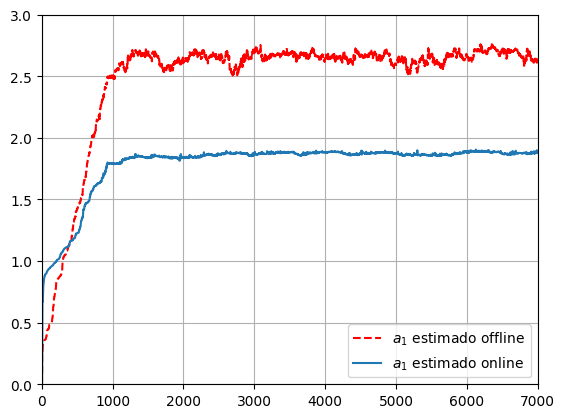

In [40]:
plt.figure()

plt.plot(theta_hatELS[:,0], 'r--')
plt.plot(a1)
plt.legend(['$a_1$ estimado offline', '$a_1$ estimado online'])
plt.ylim((0,3))
plt.xlim((0,7000))
plt.grid()


print(np.mean(a1[2000:7000]))

-0.8776487672200001


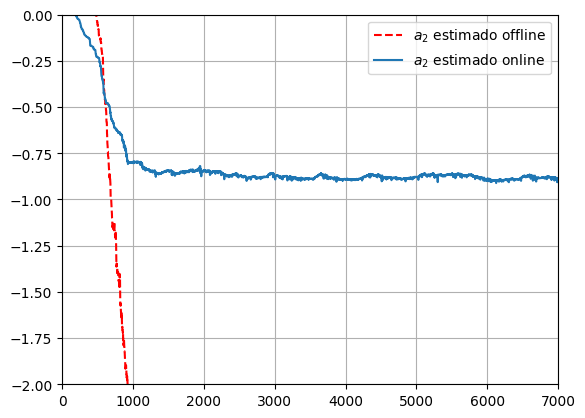

In [41]:
plt.figure()

plt.plot(theta_hatELS[:,1], 'r--')
plt.plot(a2)
plt.legend(['$a_2$ estimado offline', '$a_2$ estimado online'])
plt.ylim((-2, 0))
plt.xlim((0,7000))
plt.grid()


print(np.mean(a2[2000:7000]))

2.5182909941999998e-05


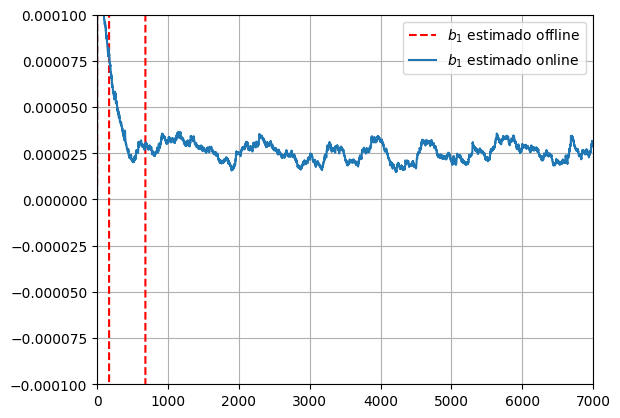

In [42]:
plt.figure()

plt.plot(theta_hatELS[:,2], 'r--')
plt.plot(b1)
plt.legend(['$b_1$ estimado offline', '$b_1$ estimado online'])
plt.ylim((-0.0001,0.0001))
plt.xlim((0,7000))
plt.grid()


print(np.mean(b1[2000:7000]))

0.2700067573


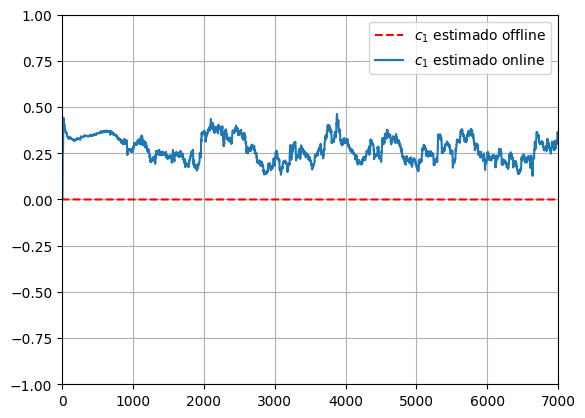

In [43]:
plt.figure()

plt.plot(theta_hatELS[:,3], 'r--')
plt.plot(c1)
plt.legend(['$c_1$ estimado offline', '$c_1$ estimado online'])
plt.ylim((-1,1))
plt.xlim((0,7000))
plt.grid()


print(np.mean(c1[2000:7000]))

##Comparación entre la medición y la estimación online a un paso

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-3167769479.py:4: SyntaxWarning: invalid escape sequence '\h'
  plt.legend(['$y$ medida', '$\hat{y}$ a un paso'])


(0.3, 0.55)

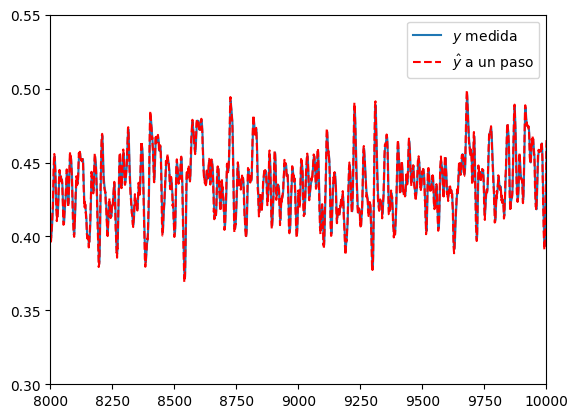

In [44]:
plt.figure()
plt.plot(yyyy)
plt.plot(yhat, 'r--')
plt.legend(['$y$ medida', '$\hat{y}$ a un paso'])
plt.xlim((8000,10000))
plt.ylim((0.3,0.55))

##Hacemos estimacion offline con los datos de la estimación online

La estimación evidentemente no pasa la prueba de la blancura, sin embargo se probó con otros órdenes para los parámetros y ninguno parece mejorar. Dado que igualmente en el ensayo de 8 minutos se observaron buenos resultados para ese modelo, continuamos el análisis

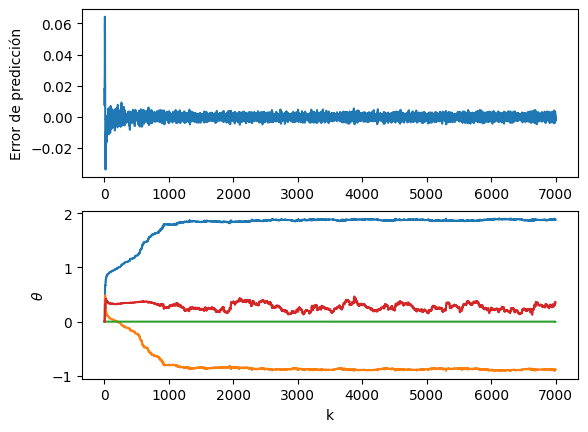

[0.00032194 0.00037573 0.00094271 ... 0.00065498 0.00066355 0.00066874]


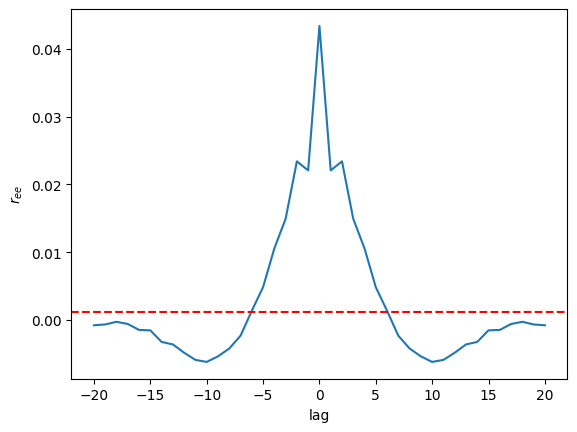

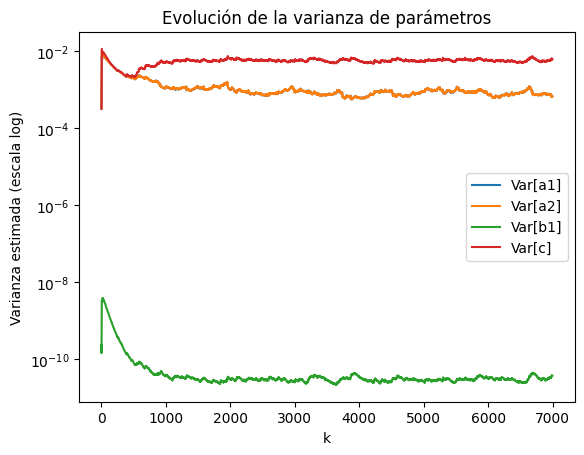

In [45]:
# Estimador por mínimos cuadrados extendido para un modelo ARX con ruido coloreado
def estimador_ELS(u,y,na=1, nb=1, nc=1, lambda_=1,theta_real=None,plot=True):
    N = len(u)
    theta_hat = np.zeros(na+nb+nc)       # estimación inicial [a_hat, b_hat]
    P = 100 * np.eye(na+nb+nc)          # matriz de covarianza grande
    err = np.zeros_like(y)

    lambda_sigma = 0.99
    sigma2_hat = 0.0

    theta_hist = []
    P_hist = []
    sigma2_hist = []

    k_range = range(na+1, N)
    for k in k_range:
        phi = np.concatenate((y[k-1:k-na-1:-1], u[k-1:k-nb-1:-1], err[k-1:k-nc-1:-1]))   # vector de regresores
     #   phi[1] = np.sin(phi[1])
        y_hat = phi @ theta_hat
        err[k] = y[k] - y_hat

        K = P @ phi / (lambda_ + phi.T @ P @ phi)
        theta_hat = theta_hat + K * err[k]
        P = (P - np.outer(K, phi) @ P) / lambda_

        sigma2_hat = lambda_sigma * sigma2_hat + (1 - lambda_sigma) * (err[k]**2)
        sigma2_hist.append(sigma2_hat)

        theta_hist.append(theta_hat.copy())
        P_hist.append(np.diag(P).copy())

    theta_hist = np.array(theta_hist)
    P_hist = np.array(P_hist)
    sigma2_hist = np.array(sigma2_hist)

    if plot:
        plt.subplot(211)
        plt.step(k_range,err[k_range],where='post')
        #plt.xlabel('Tiempo [s]')
        plt.ylabel('Error de predicción')
        plt.subplot(212)
        for idx_na in range(0,na):
            plt.step(k_range,theta_hist[:,idx_na], label=f"$\\hat{{a_{idx_na+1}}}$",where='post')
        for idx_nb in range(0,nb):
            plt.step(k_range,theta_hist[:,na+idx_nb], label=f"$\\hat{{b_{idx_nb+1}}}$",where='post')
        for idx_nc in range(0,nc):
            plt.step(k_range,theta_hist[:,na+nb+idx_nc], label=f"$\\hat{{c_{idx_nc+1}}}$",where='post')
        if theta_real!=None:
            colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
            for idx_na in range(na):
                color = colors[idx_na % len(colors)]
                plt.axhline(theta_real[idx_na], linestyle='--', color=color, label=f"$a_{idx_na}$")
            for idx_nb in range(nb):
                color = colors[(idx_nb+na) % len(colors)]
                plt.axhline(theta_real[idx_nb+na], linestyle='--', color=color, label=f"$b_{idx_nb}$")
            for idx_nc in range(nc):
                color = colors[(idx_nc+na+nb) % len(colors)]
                plt.axhline(theta_real[idx_nc+na+nb], linestyle='--', color=color, label=f"$c_{idx_nc}$")
        #plt.legend()
        plt.xlabel('k')
        plt.ylabel('$\\theta$')
        plt.show()

        # Observemos la correlación del error de predicción
        N_lag = 20
        ree = np.correlate(err,err,'full')
        lags = np.arange(-len(err)+1, len(err))
        center = len(ree) // 2
        ree = ree[center-N_lag:center+N_lag+1]
        lags_plot = lags[center-N_lag:center+N_lag+1]
        ree_max_val = 2.17/np.sqrt(N)*ree[N_lag]
        plt.figure()
        plt.plot(lags_plot,ree)
        plt.ylabel('$r_{{ee}}$')
        plt.xlabel('lag')
        plt.axhline(ree_max_val, linestyle='--', color='r', label=f"$ree_{{max}}$")
        plt.plot()
        #print(f"Error en 0 1 2 , {ree[0], ree[1] , ree[2], np.max(ree)}")
        var_a1 = sigma2_hist * P_hist[:,0]
        var_a2 = sigma2_hist * P_hist[:,1]
        var_b1 = sigma2_hist * P_hist[:,2]
        #var_b2 = sigma2_hist * P_hist[:,3]
        var_c = sigma2_hist * P_hist[:,3]
        print(var_a1)
        plt.figure()
        plt.semilogy(var_a1, label='Var[a1]')
        plt.semilogy(var_a2, label='Var[a2]')
        plt.semilogy(var_b1, label='Var[b1]')
        #plt.semilogy(var_b2, label='Var[b2]')
        plt.semilogy(var_c, label='Var[c]')
        plt.xlabel('k')
        plt.ylabel('Varianza estimada (escala log)')
        plt.legend()
        plt.title('Evolución de la varianza de parámetros')
        plt.show()


        return theta_hist,P

# --- Data ---
y = yyyy[:7000]
u = pwm[:7000]
N = len(y)


theta_hatELS,P = estimador_ELS(u,y,lambda_=0.995,na=2,nb=1,nc=1)



## Para comprobar el correco funcionamiento del algoritmo en Arduino, se comparan las estimaciones online y offline

1.874550059


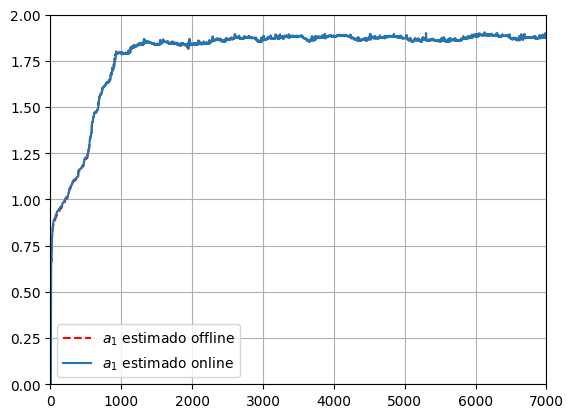

In [46]:
plt.figure()

plt.plot(theta_hatELS[:,0], 'r--')
plt.plot(a1)
plt.legend(['$a_1$ estimado offline', '$a_1$ estimado online'])
plt.ylim((0,2))
plt.xlim((0,7000))
plt.grid()


print(np.mean(a1[2000:10000]))

1.8718549180000001


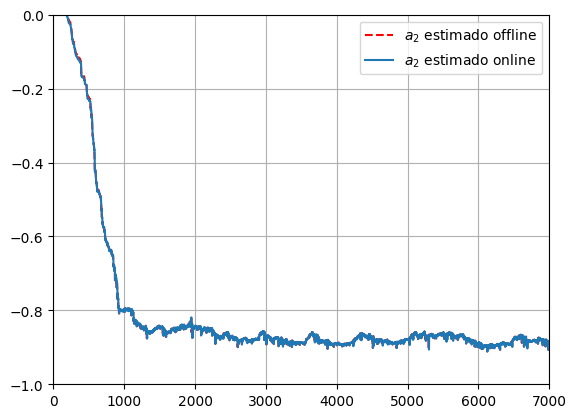

In [48]:
plt.figure()

plt.plot(theta_hatELS[:,1], 'r--')
plt.plot(a2)
plt.legend(['$a_2$ estimado offline', '$a_2$ estimado online'])
plt.ylim((-1, 0))
plt.xlim((0,7000))
plt.grid()


print(np.mean(a1[2000:7000]))

2.53046543675e-05


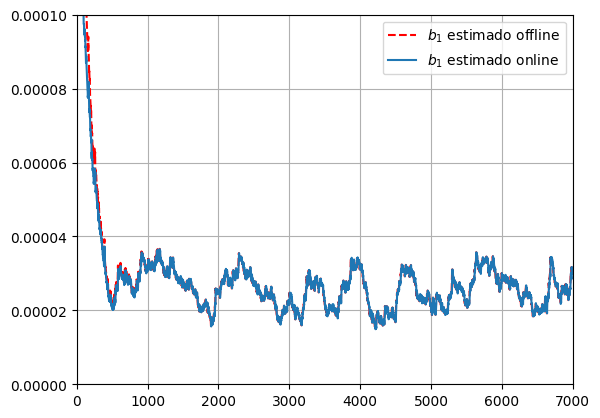

In [47]:
plt.figure()

plt.plot(theta_hatELS[:,2], 'r--')
plt.plot(b1)
plt.legend(['$b_1$ estimado offline', '$b_1$ estimado online'])
plt.ylim((0,0.0001))
plt.xlim((0,7000))
plt.grid()


print(np.mean(b1[2000:10000]))

0.2500193150875


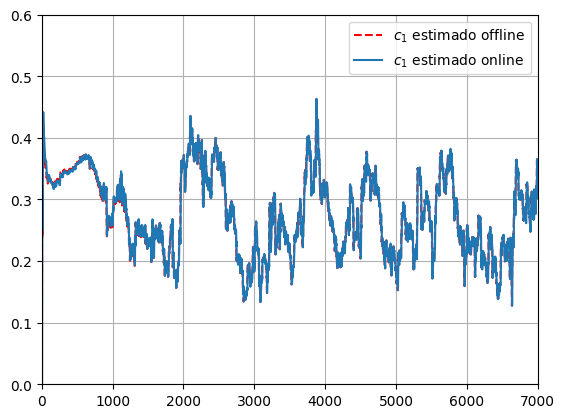

In [49]:
plt.figure()

plt.plot(theta_hatELS[:,3], 'r--')
plt.plot(c1)
plt.legend(['$c_1$ estimado offline', '$c_1$ estimado online'])
plt.ylim((0,0.6))
plt.xlim((0,7000))
plt.grid()


print(np.mean(c1[2000:10000]))

##Simulamos el modelo con los parámetros estimados online y comparamos con la medición

In [50]:
def obtener_datos(u ,e ,a1, a2, b1, b2, C, type='ARX'):
  N = len(u)
  y = np.zeros_like(u)
  if type=='ARX':
    for k in range(2, N):
      y[k] = a1*y[k-1] + a2*y[k-2] + b1*u[k-1] + b2*u[k-2] + e[k]
  elif type=='ARMAX':
    for k in range(2, N):
      y[k] = a1*y[k-1] + a2*y[k-2] + b1*u[k-1] + b2*u[k-2] + e[k] + C*e[k-1]
  elif type=='OE':
    for k in range(2, N):
      y[k] = a1*y[k-1] + a2*y[k-2] + b1*u[k-1] + b2*u[k-2]
    y = y + e;

  return y

<>:14: SyntaxWarning: invalid escape sequence '\h'
<>:14: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-2449234942.py:14: SyntaxWarning: invalid escape sequence '\h'
  plt.legend(['$y$ medida', '$\hat{y}$ simulada'])


(0.35, 0.6)

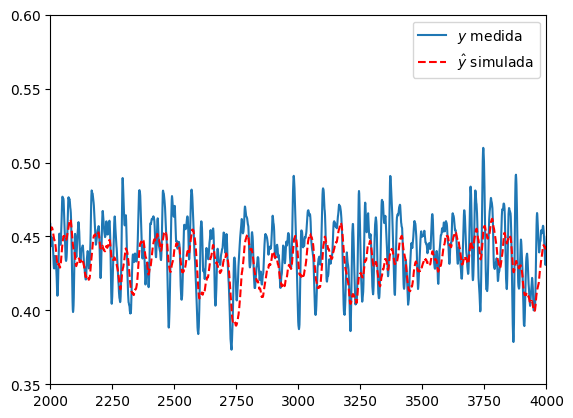

In [51]:
u = pwm[:7000]
e = np.zeros_like(u)

a1_fijo = np.mean(a1[2000:7000])
a2_fijo = np.mean(a2[2000:7000])
b1_fijo = np.mean(b1[2000:7000])
c1_fijo = np.mean(c1[2000:7000])

y_sim = obtener_datos(u, e, a1_fijo, a2_fijo, b1_fijo, 0, 0)

plt.figure()
plt.plot(yyyy)
plt.plot(y_sim, 'r--')
plt.legend(['$y$ medida', '$\hat{y}$ simulada'])
plt.xlim((2000,4000))
plt.ylim((0.35,0.6))



## Tomamos mediciones de escalones y comparamos con la planta estimada

Para mayor rigurosidad, en vez de usar directamente los parámetros promedio, se iteró sobre su intervalo de confianza y se eligió la rta de menor error cuadratico medio.

In [52]:
!curl -L -o y_esc.csv https://raw.githubusercontent.com/fadellavedova/control_adaptativo/master/mediciones/output_escalon.csv
!curl -L -o u_esc.csv https://raw.githubusercontent.com/fadellavedova/control_adaptativo/master/mediciones/input_escalon.csv


y_esc = np.loadtxt('y_esc.csv')
u = np.loadtxt('u_esc.csv')
e = np.zeros_like(u)
print(a1_fijo, a2_fijo, b1_fijo)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 87747  100 87747    0     0   238k      0 --:--:-- --:--:-- --:--:--  240k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 30432  100 30432    0     0   129k      0 --:--:-- --:--:-- --:--:--  129k
1.8718549180000001 -0.8776487672200001 2.5182909941999998e-05


<>:34: SyntaxWarning: invalid escape sequence '\h'
<>:34: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-2160931573.py:34: SyntaxWarning: invalid escape sequence '\h'
  plt.legend(['$y$ medida', '$\hat{y}$ simulada'])


0.011808236410763295 0.01181446984621263 4.568721586407368e-06 0.06501615721596983


/tmp/ipython-input-3014789454.py:6: RuntimeWarning: overflow encountered in scalar multiply
  y[k] = a1*y[k-1] + a2*y[k-2] + b1*u[k-1] + b2*u[k-2] + e[k]
/tmp/ipython-input-3014789454.py:6: RuntimeWarning: invalid value encountered in scalar add
  y[k] = a1*y[k-1] + a2*y[k-2] + b1*u[k-1] + b2*u[k-2] + e[k]


Error cuadrático medio: 0.0026848314006405268
1.8929854463139977 -0.9012777069124254 3.4320353114814736e-05


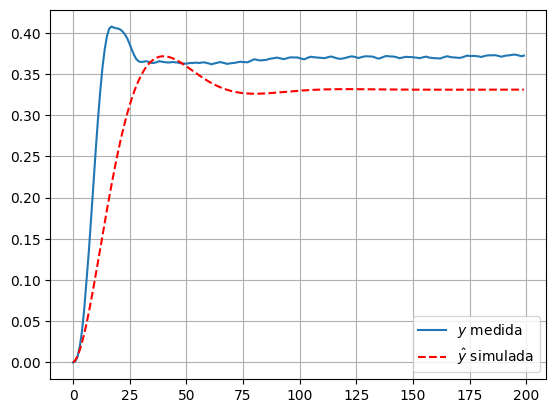

In [53]:
a1_sigma = np.std(a1[2000:7000])
a2_sigma = np.std(a2[2000:7000])
b1_sigma = np.std(b1[2000:7000])
c1_sigma = np.std(c1[2000:7000])

print(a1_sigma, a2_sigma, b1_sigma, c1_sigma)

a1_posibles = np.linspace(a1_fijo-a1_sigma*2, a1_fijo+a1_sigma*2, 20)
a2_posibles = np.linspace(a2_fijo-a2_sigma*2, a2_fijo+a2_sigma*2, 20)
b1_posibles = np.linspace(b1_fijo-b1_sigma*2, b1_fijo+b1_sigma*2, 20)
c1_posibles = np.linspace(c1_fijo-c1_sigma*2, c1_fijo+c1_sigma*2, 10)

mse_min = 10

for a11 in a1_posibles:
  for a21 in a2_posibles:
    for b11 in b1_posibles:
      y_sim = obtener_datos(u, e, a11, a21, b11, 0, c1_fijo)
      mse = np.sum((y_esc[2000:2200] - y_sim[2000:2200])**2)/200
      if mse < mse_min:
        mse_min = mse

        y_best = y_sim
        a1_best = a11
        a2_best = a21
        b1_best = b11

y_sim = obtener_datos(u, e, a1_best, a2_best, b1_best, 0, c1_fijo)

plt.figure()
plt.plot(y_esc[2000:2200] - y_esc[2000])
plt.plot(y_best[2000:2200] - y_best[2000], 'r--')
plt.grid()
plt.legend(['$y$ medida', '$\hat{y}$ simulada'])

print(f"Error cuadrático medio: {mse_min}")

print(a1_best, a2_best, b1_best)
